# Supp Fig 10 — tuft-like signature stratifies relapse (TCGA)

Reproduces **SuppFig10** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 10 — TCGA-CRC FP-specific KM/Cox (cell 121)
**🔴 heavy (GPU / multi-GB / long)** · source: `umap_FN_FP_clusters.ipynb cell 121`

In [ ]:
# ── TCGA-CRC OS analysis with FP-specific cluster signature ──
import json as _json
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

TCGA_CACHE = NB / '_tcga_cache'
TCGA_H5AD  = TCGA_CACHE / 'tcga_crc_adata_lognorm.h5ad'
CLIN_CACHE = TCGA_CACHE / 'tcga_crc_clinical.json'
F2C_CACHE  = TCGA_CACHE / 'tcga_file_to_case.csv'

# ── 1) FP-specific signature from pydeseq2 DE ──
# Load NEW signature (one-vs-rest, vs all other cells incl. TME)
sig_path = OUT_DIR / 'FP_specific_signature_OvR.csv'
sig_df = pd.read_csv(sig_path)
FP_SPEC_SIG = sig_df['gene'].astype(str).tolist()
print(f'FP-specific signature (OvR, file={sig_path.name}): {len(FP_SPEC_SIG)} genes')
print(f'  top 15: {FP_SPEC_SIG[:15]}')

# ── 2) Load TCGA expression + score ──
print('\nLoading TCGA cache ...', flush=True)
tcga = ad.read_h5ad(TCGA_H5AD)
print(f'  TCGA: {tcga.shape}')

present = [g for g in FP_SPEC_SIG if g in tcga.var_names]
missing = [g for g in FP_SPEC_SIG if g not in tcga.var_names]
print(f'  Signature in TCGA panel: {len(present)}/{len(FP_SPEC_SIG)}  missing: {missing}')
if len(present) < 5:
    raise RuntimeError('Too few signature genes in TCGA — abort.')

sc.tl.score_genes(tcga, gene_list=present, score_name='FP_spec_sig',
                   random_state=42, use_raw=False)
print(f'  score range: [{tcga.obs["FP_spec_sig"].min():.3f}, {tcga.obs["FP_spec_sig"].max():.3f}]')

# ── 3) Clinical survival table ──
with open(CLIN_CACHE) as f:
    clin_hits = _json.load(f)
print(f'\nClinical entries: {len(clin_hits)}')
rows = []
for h in clin_hits:
    case = h.get('submitter_id')
    diag = (h.get('diagnoses') or [{}])[0]
    demo = h.get('demographic') or {}
    stage = diag.get('ajcc_pathologic_stage')
    vital = demo.get('vital_status', '')
    dod   = demo.get('days_to_death')
    dlf   = diag.get('days_to_last_follow_up')
    if vital == 'Dead' and dod is not None:
        time_d, event = dod, 1
    elif dlf is not None:
        time_d, event = dlf, 0
    else:
        time_d, event = None, None
    rows.append({'case_id': case, 'time': time_d, 'event': event,
                  'stage': stage, 'vital_status': vital,
                  'age': demo.get('age_at_index'), 'sex': demo.get('gender')})
clin = pd.DataFrame(rows).dropna(subset=['time', 'event'])
clin['time']   = clin['time'].astype(float)
clin['event']  = clin['event'].astype(int)
clin['time_months'] = clin['time'] / 30.4375
print(f'  with OS: {len(clin)}  events (deaths): {int(clin["event"].sum())}')

# ── 4) file_id → case_id mapping ──
f2c = pd.read_csv(F2C_CACHE)
print(f'  file→case: {len(f2c)} entries')
# Only Primary Tumor samples (avoid duplicates from metastatic / normal-adjacent)
if 'sample_type' in f2c.columns:
    f2c_pt = f2c[f2c['sample_type'].str.contains('Primary Tumor', na=False)]
    print(f'  primary-tumor files only: {len(f2c_pt)} / {len(f2c)}')
    f2c = f2c_pt
f2c_dict = dict(zip(f2c['file_id'].astype(str), f2c['case_id'].astype(str)))

score_df = tcga.obs[['FP_spec_sig']].copy()
score_df.index = score_df.index.astype(str)
score_df['case_id'] = score_df.index.map(f2c_dict)
score_df = score_df.dropna(subset=['case_id'])
# 1 case = 1 score (mean if multiple primary tumor files exist)
score_per_case = score_df.groupby('case_id')['FP_spec_sig'].mean().reset_index()
print(f'  scored cases (Primary Tumor): {len(score_per_case)}')

surv = score_per_case.merge(clin, on='case_id', how='inner')
print(f'\nMerged survival table: n={len(surv)}, events={int(surv["event"].sum())}')

# ── 5) KM curves + log-rank ──
C_LOW, C_MID, C_HIGH = '#3D5F87', '#9CA3AF', '#cc3322'

def km_panel(ax, df, score_col, split='median'):
    df = df.copy()
    if split == 'median':
        thr = df[score_col].median()
        df['grp'] = np.where(df[score_col] >= thr, 'high', 'low')
        order  = ['low', 'high']
        colors = {'low': C_LOW, 'high': C_HIGH}
    else:  # tertile
        q1, q2 = df[score_col].quantile([1/3, 2/3])
        df['grp'] = np.where(df[score_col] >= q2, 'high',
                              np.where(df[score_col] <= q1, 'low', 'mid'))
        order  = ['low', 'mid', 'high']
        colors = {'low': C_LOW, 'mid': C_MID, 'high': C_HIGH}
    kmf = KaplanMeierFitter()
    for g in order:
        sub = df[df['grp'] == g]
        if sub.empty: continue
        kmf.fit(sub['time_months'], sub['event'], label=f'{g} (n={len(sub)})')
        kmf.plot_survival_function(ax=ax, color=colors[g], ci_show=False)
    if split == 'median':
        a = df[df['grp'] == 'low']; b = df[df['grp'] == 'high']
        r = logrank_test(a['time_months'], b['time_months'],
                          event_observed_A=a['event'], event_observed_B=b['event'])
        p = r.p_value
    else:
        r = multivariate_logrank_test(df['time_months'], df['grp'], df['event'])
        p = r.p_value
    ax.text(0.97, 0.03, f'log-rank p={p:.2e}', transform=ax.transAxes,
             ha='right', va='bottom', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel('Months', fontsize=11)
    ax.set_ylabel('OS probability', fontsize=11)
    ax.set_title(f'{score_col}  ({split} split)', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
    return p

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p_med = km_panel(axes[0], surv, 'FP_spec_sig', split='median')
p_ter = km_panel(axes[1], surv, 'FP_spec_sig', split='tertile')
fig.suptitle(f'TCGA-CRC OS by FP-specific cluster signature (n={len(surv)}, '
              f'events={int(surv["event"].sum())})',
              fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'tcga_FPspecific_km.{ext}', dpi=170, bbox_inches='tight')
print(f'\nSaved: {OUT_DIR / "tcga_FPspecific_km"}.{{png,pdf}}')
plt.show()

# ── 6) Cox PH (univariate / +stage / +stage+age) ──
STAGE_MAP = {
    'Stage I':'I','Stage IA':'I','Stage IB':'I',
    'Stage II':'II','Stage IIA':'II','Stage IIB':'II','Stage IIC':'II',
    'Stage III':'III','Stage IIIA':'III','Stage IIIB':'III','Stage IIIC':'III',
    'Stage IV':'IV','Stage IVA':'IV','Stage IVB':'IV','Stage IVC':'IV',
}
surv['stage_grp'] = surv['stage'].map(STAGE_MAP)

def cox_fit(df, score, adjust=None):
    cols = ['time_months', 'event', score]
    if adjust: cols += adjust
    d = df[cols].dropna().copy()
    if adjust and 'stage_grp' in adjust:
        d = pd.get_dummies(d, columns=['stage_grp'], drop_first=True, dtype=float)
    cph = CoxPHFitter()
    cph.fit(d, duration_col='time_months', event_col='event')
    return cph

cox_rows = []
for adj_name, adj_cols in [('univariate', None),
                            ('+ stage',         ['stage_grp']),
                            ('+ stage + age',   ['stage_grp', 'age'])]:
    try:
        cph = cox_fit(surv, 'FP_spec_sig', adjust=adj_cols)
        row = cph.summary.loc['FP_spec_sig']
        cox_rows.append({
            'model': adj_name,
            'n': int(cph._n_examples),
            'n_events': int(cph.event_observed.sum()),
            'HR':       float(np.exp(row['coef'])),
            'HR_95L':   float(np.exp(row['coef lower 95%'])),
            'HR_95U':   float(np.exp(row['coef upper 95%'])),
            'p':        float(row['p']),
            'concordance': float(cph.concordance_index_),
        })
    except Exception as e:
        print(f'  Cox failed for {adj_name}: {e}')

cox_df = pd.DataFrame(cox_rows)
cox_df.to_csv(OUT_DIR / 'tcga_FPspecific_cox.csv', index=False)
print('\nCox PH (HR for 1-SD increase in FP_spec_sig):')
print(cox_df.to_string(index=False))

# ── 7) Forest plot ──
fig, ax = plt.subplots(figsize=(9, max(2.5, len(cox_df) * 0.75)))
y = np.arange(len(cox_df))[::-1]
for yi, r in zip(y, cox_df.itertuples()):
    ax.errorbar(r.HR, yi,
                 xerr=[[max(r.HR - r.HR_95L, 1e-6)], [max(r.HR_95U - r.HR, 1e-6)]],
                 fmt='o', color='black', ecolor='black',
                 markersize=8, capsize=5, lw=1.1)
    star = ('****' if r.p < 1e-4 else '***' if r.p < 1e-3
             else '**' if r.p < 1e-2 else '*' if r.p < 0.05 else 'ns')
    ax.text(r.HR_95U * 1.05, yi,
             f'HR={r.HR:.2f} [{r.HR_95L:.2f}-{r.HR_95U:.2f}]  p={r.p:.2g}  {star}',
             va='center', fontsize=10)
ax.axvline(1.0, ls=':', color='gray', lw=1.0)
ax.set_yticks(y); ax.set_yticklabels(cox_df['model'], fontsize=11)
ax.set_xscale('log')
ax.set_xlabel('Hazard Ratio (log scale, per 1-SD score)', fontsize=11)
ax.set_title(f'FP-specific signature — Cox PH HR for OS  (n={int(cox_df["n"].iloc[0])})',
              fontsize=12, fontweight='bold')
ax.set_xlim(left=min(cox_df['HR_95L'].min() / 1.3, 0.5),
             right=cox_df['HR_95U'].max() * 4.5)
for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'tcga_FPspecific_cox_forest.{ext}', dpi=170, bbox_inches='tight')
print(f'\nSaved: {OUT_DIR / "tcga_FPspecific_cox_forest"}.{{png,pdf}}')
plt.show()

# ── 8) Stage II/III subgroup KM ──
stage23 = surv[surv['stage_grp'].isin(['II', 'III'])].copy()
print(f'\nStage II/III subset: n={len(stage23)}, events={int(stage23["event"].sum())}')
if len(stage23) >= 30:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    km_panel(axes[0], stage23, 'FP_spec_sig', split='median')
    km_panel(axes[1], stage23, 'FP_spec_sig', split='tertile')
    fig.suptitle(f'TCGA-CRC Stage II/III OS by FP-specific cluster signature '
                  f'(n={len(stage23)})',
                  fontsize=13, fontweight='bold', y=1.02)
    fig.tight_layout()
    for ext in ('png','pdf'):
        fig.savefig(OUT_DIR / f'tcga_FPspecific_km_stage23.{ext}',
                     dpi=170, bbox_inches='tight')
    print(f'Saved: {OUT_DIR / "tcga_FPspecific_km_stage23"}.{{png,pdf}}')
    plt.show()
else:
    print('  Stage II/III subset too small (<30) — skipping subgroup KM')

# ── 9) Save signature + per-case table ──
pd.Series(FP_SPEC_SIG, name='gene').to_csv(
    OUT_DIR / 'tcga_FPspecific_signature_genes.csv', index=False)
surv.to_csv(OUT_DIR / 'tcga_FPspecific_perCase_survival.csv', index=False)
print(f'\nSaved signature genes + per-case survival table.')

### Supp Fig 10 — TCGA-COAD/READ stratified KM (cell 211, md desc=210)
**🟡 moderate** · source: `umap_FN_FP_clusters.ipynb cell 211`

In [ ]:
# ── TCGA-COAD/READ 層別化 KM (Colon vs Rectum) ──
print('\n=== TCGA-COAD vs TCGA-READ stratified KM ===')

# Reload TCGA-CDR with `type` column preserved
cdr_full = pd.read_excel(CDR_PATH, sheet_name='TCGA-CDR', engine='openpyxl')
cdr_crc_typed = cdr_full[cdr_full['type'].isin(['COAD','READ'])][
    ['bcr_patient_barcode','type','DFI','DFI.time']].rename(
    columns={'bcr_patient_barcode':'case_id','DFI':'event','DFI.time':'time_days'}).dropna()
cdr_crc_typed['time_months'] = cdr_crc_typed['time_days'] / 30.4375
cdr_crc_typed['event']       = cdr_crc_typed['event'].astype(int)

print(f'  COAD patients with DFI: {(cdr_crc_typed["type"]=="COAD").sum()}, '
       f'events: {int(cdr_crc_typed.loc[cdr_crc_typed["type"]=="COAD","event"].sum())}')
print(f'  READ patients with DFI: {(cdr_crc_typed["type"]=="READ").sum()}, '
       f'events: {int(cdr_crc_typed.loc[cdr_crc_typed["type"]=="READ","event"].sum())}')

# Use existing `sd` (TCGA signature score per case_id from extval-code)
if 'sd' not in dir():
    present_sig = [g for g in FP_SIG if g in tcga.var_names]
    sc.tl.score_genes(tcga, gene_list=present_sig, score_name='FP_spec_sig',
                       random_state=42, use_raw=False)
    sd = tcga.obs[['FP_spec_sig']].copy()
    sd['case_id'] = sd.index.astype(str).map(f2c_d)
    sd = sd.dropna().groupby('case_id')['FP_spec_sig'].mean().reset_index()

# Stratified KM
for cancer_type in ['COAD', 'READ']:
    print(f'\n--- [TCGA-{cancer_type}] ---')
    sub_cdr = cdr_crc_typed[cdr_crc_typed['type'] == cancer_type]
    surv_t = sd.merge(sub_cdr[['case_id','time_months','event']], on='case_id', how='inner')
    print(f'  Merged: n={len(surv_t)} (events {int(surv_t["event"].sum())})')

    label_str = 'TCGA-COAD (Colon)' if cancer_type == 'COAD' else 'TCGA-READ (Rectum)'
    fname_str = f'extval_TCGA_DFI_KM_{cancer_type}'
    s_t = youden_km(surv_t, 'FP_spec_sig', 'time_months', 'event',
                     f'{label_str} — FP-specific signature → DFI', fname_str)
    if s_t:
        s_t['cohort'] = f'TCGA_DFI_{cancer_type}'
        all_stats.append(s_t)

    # POU2F3 only (per cancer type)
    if 'POU2F3' in tcga.var_names:
        if 'POU2F3_expr' not in tcga.obs.columns:
            import scipy.sparse as _sp
            pou_x = tcga[:, 'POU2F3'].X
            if _sp.issparse(pou_x): pou_x = pou_x.toarray()
            tcga.obs['POU2F3_expr'] = np.asarray(pou_x).ravel()
        sd_pou = tcga.obs[['POU2F3_expr']].copy()
        sd_pou['case_id'] = sd_pou.index.astype(str).map(f2c_d)
        sd_pou = sd_pou.dropna().groupby('case_id')['POU2F3_expr'].mean().reset_index()
        surv_t_p = sd_pou.merge(sub_cdr[['case_id','time_months','event']], on='case_id', how='inner')
        s_t_p = youden_km(surv_t_p, 'POU2F3_expr', 'time_months', 'event',
                           f'{label_str} — POU2F3 expression → DFI',
                           f'extval_TCGA_DFI_POU2F3_KM_{cancer_type}')
        if s_t_p:
            s_t_p['cohort'] = f'TCGA_DFI_POU2F3_{cancer_type}'
            all_stats.append(s_t_p)

# Update combined stats CSV
stats_df = pd.DataFrame(all_stats)
stats_df.to_csv(OUT_DIR / 'extval_combined_stats.csv', index=False)
print(f'\nUpdated: extval_combined_stats.csv')
print(stats_df.to_string(index=False))

### Supp Fig 10 — TCGA signature survival (setup)
**🟡 moderate** · source: `signature_survival_tcga.ipynb cells 2,4,6,8,10`

In [ ]:
from pathlib import Path
import json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

ROOT       = REPO_ROOT
DEG_DIR    = ROOT / 'notebooks/comparison_results/deg_TP_FP_TN_FN'
TCGA_CACHE = ROOT / 'notebooks/_tcga_cache'
COUNTS_DIR = TCGA_CACHE / 'counts'
CLIN_CACHE = TCGA_CACHE / 'tcga_crc_clinical.json'
OUT_DIR    = ROOT / 'notebooks/comparison_results/signature_survival_tcga'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ADATA_CACHE = TCGA_CACHE / 'tcga_crc_adata_lognorm.h5ad'

# Palette
C_HIGH = '#F4B183'   # high signature = orange (Tumor-like)
C_LOW  = '#9DC3E6'   # low signature = blue
C_MID  = '#BFBFBF'   # tertile middle = gray

SIGNATURES = ['FP_sig', 'FN_sig']  # display order


inter = pd.read_csv(DEG_DIR / 'venn_intersection_genes.csv')
print('available directions:', inter['direction'].unique())
FP_sig_genes = set(inter.loc[inter['direction']=='FP_up', 'gene'].astype(str))
FN_sig_genes = set(inter.loc[inter['direction']=='FN_up', 'gene'].astype(str))
print(f'FP_sig (orig=N / SPATNIC=T, n_genes={len(FP_sig_genes):,})')
print(f'FN_sig (orig=T / SPATNIC=N, n_genes={len(FN_sig_genes):,})')
SIG_GENES = {'FP_sig': FP_sig_genes, 'FN_sig': FN_sig_genes}


def parse_counts(file_id):
    df = pd.read_csv(COUNTS_DIR / f'{file_id}.tsv', sep='\t', skiprows=1)
    df = df[~df['gene_id'].astype(str).str.startswith('N_')]
    return df.groupby('gene_name')['unstranded'].sum()

def build_adata():
    files = sorted(p.stem for p in COUNTS_DIR.glob('*.tsv'))
    print(f'  {len(files)} count files', flush=True)
    series, keep = [], []
    for i, fid in enumerate(files):
        try:
            s = parse_counts(fid); series.append(s); keep.append(fid)
        except Exception as e:
            print(f'    skip {fid}: {e}')
        if (i+1) % 100 == 0: print(f'    parsed {i+1}/{len(files)}', flush=True)
    X = pd.concat(series, axis=1).fillna(0).astype(np.int32).T
    X.index = keep
    a = ad.AnnData(X=X.values, obs=pd.DataFrame(index=X.index),
                    var=pd.DataFrame(index=X.columns))
    a.layers['counts'] = a.X.copy()
    sc.pp.normalize_total(a)
    sc.pp.log1p(a)
    a.var_names_make_unique()
    return a

if ADATA_CACHE.exists():
    print(f'  cache hit: {ADATA_CACHE.name}', flush=True)
    adata = ad.read_h5ad(ADATA_CACHE)
else:
    t0 = time.time()
    adata = build_adata()
    print(f'  built in {time.time()-t0:.1f}s; saving …', flush=True)
    adata.write(ADATA_CACHE)
print(f'TCGA adata: {adata.shape}  (samples × genes)')


for sig_name, genes in SIG_GENES.items():
    present = [g for g in genes if g in adata.var_names]
    missing = len(genes) - len(present)
    print(f'  {sig_name}: {len(present):,} / {len(genes):,} in TCGA  (missing {missing})')
    sc.tl.score_genes(adata, gene_list=present, score_name=sig_name,
                      random_state=42, use_raw=False)

score_df = adata.obs[SIGNATURES].copy()
print(score_df.describe())


with open(CLIN_CACHE) as f:
    clin_hits = json.load(f)
print(f'  clinical cases: {len(clin_hits)}')

rows = []
for h in clin_hits:
    case = h.get('submitter_id')
    diag = (h.get('diagnoses') or [{}])[0]
    demo = h.get('demographic') or {}
    stage = diag.get('ajcc_pathologic_stage')
    # OS time: prefer demographic.days_to_death; if alive (vital_status), days_to_last_follow_up
    vital = demo.get('vital_status', '')
    dod   = demo.get('days_to_death')
    dlf   = diag.get('days_to_last_follow_up')
    if vital == 'Dead' and dod is not None:
        time_d = dod; event = 1
    elif dlf is not None:
        time_d = dlf; event = 0
    else:
        time_d = None; event = None
    rows.append({'case_id': case, 'time': time_d, 'event': event,
                  'stage': stage, 'vital_status': vital,
                  'age': demo.get('age_at_index'),
                  'sex': demo.get('gender')})
clin = pd.DataFrame(rows).dropna(subset=['time','event'])
clin['time'] = clin['time'].astype(float)
clin['event'] = clin['event'].astype(int)
# Time -> months (TCGA days)
clin['time_months'] = clin['time'] / 30.4375
print(f'  clinical with OS: {len(clin)}, events (deaths): {clin["event"].sum()}')
print(f'  stage distribution: {clin["stage"].value_counts(dropna=False).head(8).to_dict()}')

# Map file_id -> case submitter_id via GDC file-to-case API.
# Use file_id column from the existing adata.obs index (file uuids) + GDC cases endpoint.
# Simpler shortcut: many TCGA count files have submitter_id-like patterns embedded;
# but file_id is uuid. We need a mapping table from the same source as cache.
# Use existing file list query as in apply_to_bulk_tcga; re-query for case ids.
import requests
MAP_CACHE = TCGA_CACHE / 'tcga_file_to_case.csv'
if MAP_CACHE.exists():
    f2c = pd.read_csv(MAP_CACHE)
    print(f'  file→case cache: {len(f2c)} rows')
else:
    file_ids = list(adata.obs_names)
    f2c_rows = []
    print('  fetching file→case mapping from GDC (chunked) …', flush=True)
    BATCH = 100
    for i in range(0, len(file_ids), BATCH):
        chunk = file_ids[i:i+BATCH]
        body = {
            'filters': {'op': 'in', 'content': {'field': 'file_id', 'value': chunk}},
            'fields': 'file_id,cases.submitter_id,cases.samples.sample_type',
            'format': 'json', 'size': BATCH,
        }
        r = requests.post('https://api.gdc.cancer.gov/files', json=body, timeout=120)
        r.raise_for_status()
        hits = r.json()['data']['hits']
        for h in hits:
            case = (h.get('cases') or [{}])[0]
            samples = (case.get('samples') or [{}])
            stype = samples[0].get('sample_type', 'NA') if samples else 'NA'
            f2c_rows.append({'file_id': h['file_id'],
                              'case_id': case.get('submitter_id'),
                              'sample_type': stype})
        print(f'    {min(i+BATCH, len(file_ids))}/{len(file_ids)}', flush=True)
    f2c = pd.DataFrame(f2c_rows)
    f2c.to_csv(MAP_CACHE, index=False)
    print(f'  cached → {MAP_CACHE}')
print(f'  sample_type counts: {f2c["sample_type"].value_counts().to_dict()}')

# Restrict to primary tumors only
primary = f2c[f2c['sample_type'].astype(str).str.contains('Primary', na=False)].copy()
print(f'  primary-tumor files: {len(primary)}')

# Build per-sample analytic table: signature scores + clinical
score_with_case = score_df.copy()
score_with_case.index.name = 'file_id'
score_with_case = score_with_case.reset_index().merge(primary[['file_id','case_id']],
                                                       on='file_id', how='inner')
# If a case has multiple primary files, average their scores
score_with_case = score_with_case.groupby('case_id', as_index=False)[SIGNATURES].mean()
surv = clin.merge(score_with_case, on='case_id', how='inner')
print(f'\n  joined surv table: {len(surv)} cases with both clinical & scores')
surv.to_csv(OUT_DIR / 'tcga_signature_scores.csv', index=False)
print(f'Saved: {OUT_DIR / "tcga_signature_scores.csv"}')

### Supp Fig 10 — KM curves
**🟢 light (reads caches)** · source: `signature_survival_tcga.ipynb cell 12`

In [ ]:
def km_panel(ax, df, score, split='median'):
    if split == 'median':
        thr = df[score].median()
        df = df.copy(); df['grp'] = np.where(df[score] >= thr, 'high', 'low')
        order = ['low', 'high']
        colors = {'low': C_LOW, 'high': C_HIGH}
    elif split == 'tertile':
        q1, q2 = df[score].quantile([1/3, 2/3])
        df = df.copy()
        df['grp'] = np.where(df[score] >= q2, 'high',
                              np.where(df[score] <= q1, 'low', 'mid'))
        order = ['low', 'mid', 'high']
        colors = {'low': C_LOW, 'mid': C_MID, 'high': C_HIGH}
    kmf = KaplanMeierFitter()
    for g in order:
        sub = df[df['grp']==g]
        if sub.empty: continue
        kmf.fit(sub['time_months'], sub['event'], label=f'{g} (n={len(sub)})')
        kmf.plot_survival_function(ax=ax, color=colors[g], ci_show=False)
    # log-rank
    if split == 'median':
        a = df[df['grp']=='low']; b = df[df['grp']=='high']
        if len(a) and len(b):
            r = logrank_test(a['time_months'], b['time_months'],
                              event_observed_A=a['event'], event_observed_B=b['event'])
            p = r.p_value
    else:
        r = multivariate_logrank_test(df['time_months'], df['grp'], df['event'])
        p = r.p_value
    ax.text(0.97, 0.03, f'log-rank p={p:.2e}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel('Months', fontsize=11)
    ax.set_ylabel('OS probability', fontsize=11)
    ax.set_title(f'{score}  ({split} split)', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)

for sig in SIGNATURES:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
    km_panel(axes[0], surv, sig, split='median')
    km_panel(axes[1], surv, sig, split='tertile')
    fig.suptitle(f'TCGA-CRC OS by {sig}  (n={len(surv)})',
                  fontsize=13, fontweight='bold', y=1.01)
    fig.tight_layout()
    out = OUT_DIR / f'km_{sig}'
    for ext in ('png','pdf'):
        fig.savefig(f'{out}.{ext}', dpi=170, bbox_inches='tight')
    print(f'Saved: {out}.{{png,pdf}}')
    plt.show()

### Supp Fig 10 — Cox forest & stage II/III
**🟢 light (reads caches)** · source: `signature_survival_tcga.ipynb cells 14,16,18`

In [ ]:
STAGE_MAP = {
    'Stage I':'I','Stage IA':'I','Stage IB':'I',
    'Stage II':'II','Stage IIA':'II','Stage IIB':'II','Stage IIC':'II',
    'Stage III':'III','Stage IIIA':'III','Stage IIIB':'III','Stage IIIC':'III',
    'Stage IV':'IV','Stage IVA':'IV','Stage IVB':'IV','Stage IVC':'IV',
}
surv['stage_grp'] = surv['stage'].map(STAGE_MAP)

def cox_summary(df, score, adjust=None):
    cols = ['time_months', 'event', score]
    if adjust: cols += adjust
    d = df[cols].dropna().copy()
    # Categorical dummies if needed
    if adjust and 'stage_grp' in adjust:
        d = pd.get_dummies(d, columns=['stage_grp'], drop_first=True, dtype=float)
    cph = CoxPHFitter()
    cph.fit(d, duration_col='time_months', event_col='event')
    return cph

cox_rows = []
for sig in SIGNATURES:
    for adj_name, adj_cols in [('univariate', None), ('+stage', ['stage_grp'])]:
        try:
            cph = cox_summary(surv, sig, adjust=adj_cols)
            row = cph.summary.loc[sig].copy()
            cox_rows.append({
                'signature': sig, 'model': adj_name,
                'n': int(cph._n_examples), 'n_events': int(cph.event_observed.sum()),
                'HR': float(np.exp(row['coef'])),
                'HR_95L': float(np.exp(row['coef lower 95%'])),
                'HR_95U': float(np.exp(row['coef upper 95%'])),
                'p': float(row['p']),
                'concordance': float(cph.concordance_index_),
            })
        except Exception as e:
            print(f'  Cox failed {sig}/{adj_name}: {e}')
cox_df = pd.DataFrame(cox_rows)
cox_df.to_csv(OUT_DIR / 'cox_univariate.csv', index=False)
print(f'Saved: {OUT_DIR / "cox_univariate.csv"}')
print(cox_df.to_string(index=False))


stage23 = surv[surv['stage_grp'].isin(['II','III'])].copy()
print(f'  Stage II/III subset: n={len(stage23)}, events={int(stage23["event"].sum())}')

fig, axes = plt.subplots(1, len(SIGNATURES), figsize=(6.5*len(SIGNATURES), 5))
for ax, sig in zip(axes, SIGNATURES):
    km_panel(ax, stage23, sig, split='median')
    ax.set_title(f'{sig}  (Stage II/III, median split)', fontsize=12, fontweight='bold')
fig.suptitle(f'TCGA-CRC Stage II/III OS by signature  (n={len(stage23)})',
              fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'km_subgroup_stage23.{ext}', dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "km_subgroup_stage23"}.{{png,pdf}}')
plt.show()


d = surv[['time_months','event','stage_grp'] + SIGNATURES].dropna().copy()
d = pd.get_dummies(d, columns=['stage_grp'], drop_first=True, dtype=float)
cph = CoxPHFitter()
cph.fit(d, duration_col='time_months', event_col='event')
print(f'  combined Cox: n={int(cph._n_examples)}, events={int(cph.event_observed.sum())}')
print(f'  concordance index: {cph.concordance_index_:.3f}')
summary = cph.summary.copy()
summary['HR'] = np.exp(summary['coef'])
summary['HR_95L'] = np.exp(summary['coef lower 95%'])
summary['HR_95U'] = np.exp(summary['coef upper 95%'])
summary[['HR','HR_95L','HR_95U','p']].to_csv(OUT_DIR / 'cox_combined.csv')
print(f'Saved: {OUT_DIR / "cox_combined.csv"}')
display = summary[['HR','HR_95L','HR_95U','p']].copy()
print(display.to_string())

# Forest-like plot
fig, ax = plt.subplots(figsize=(8, 0.6*len(display)+1))
y = np.arange(len(display))[::-1]
ax.errorbar(display['HR'], y,
             xerr=[display['HR']-display['HR_95L'], display['HR_95U']-display['HR']],
             fmt='o', color='black', capsize=4, lw=1.0)
ax.axvline(1.0, color='gray', linestyle='--', lw=0.8)
for i, (idx, row) in enumerate(display.iterrows()):
    p_str = '***' if row['p']<1e-3 else '**' if row['p']<1e-2 else '*' if row['p']<0.05 else 'ns'
    ax.text(display['HR_95U'].max()*1.05, y[i],
            f'HR={row["HR"]:.2f} [{row["HR_95L"]:.2f}-{row["HR_95U"]:.2f}]  p={row["p"]:.2e} {p_str}',
            va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(display.index, fontsize=10)
ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
ax.set_xscale('log')
ax.set_xlim(display['HR_95L'].min()*0.6, display['HR_95U'].max()*3.5)
ax.set_title(f'Combined Cox PH — TCGA-CRC OS  (n={int(cph._n_examples)}, '
              f'C-index={cph.concordance_index_:.3f})',
              fontsize=12, fontweight='bold')
for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.tight_layout()
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'cox_combined_forest.{ext}', dpi=170, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "cox_combined_forest"}.{{png,pdf}}')
plt.show()

## Published result (reference)
Embedded reference output; the code above regenerates it.

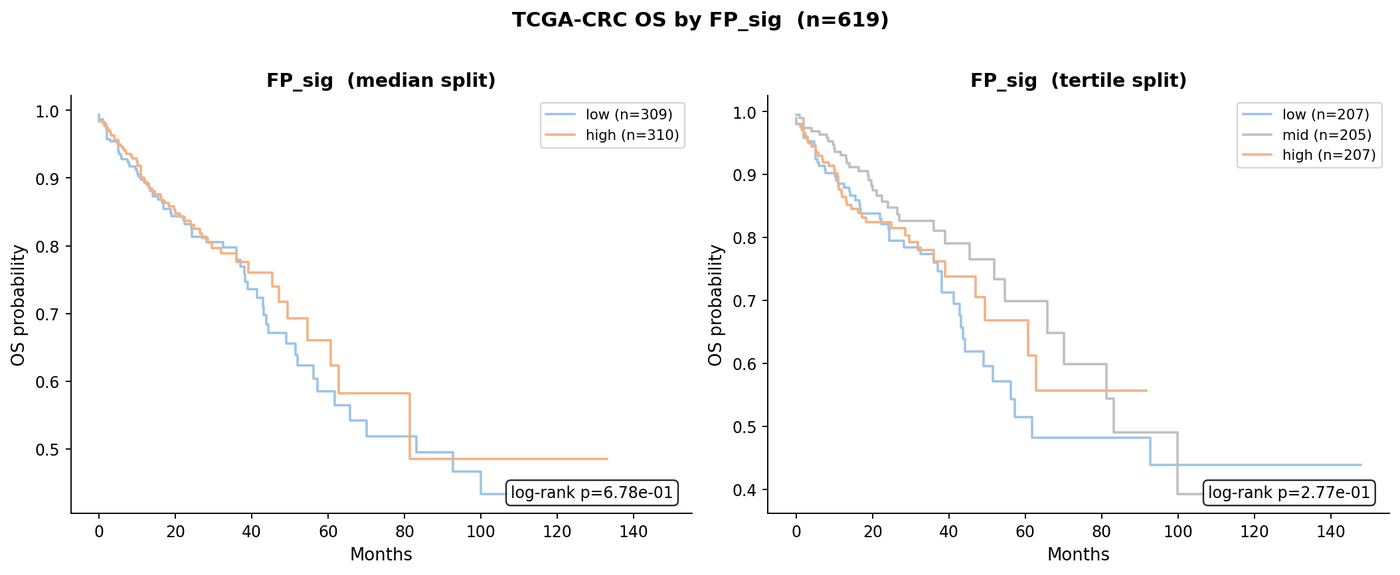

In [ ]:
# KM by signature (FP)
Image(str(COMP / "signature_survival_tcga/km_FP_sig.png"))

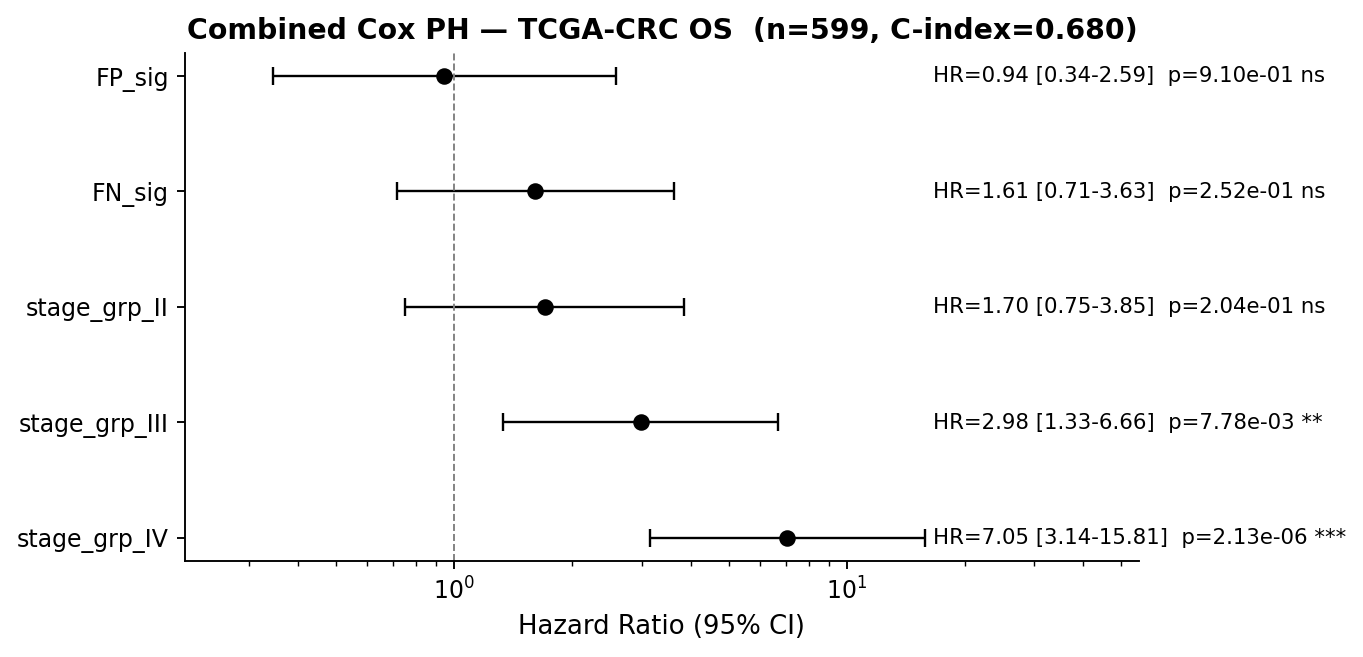

In [ ]:
# Cox forest
Image(str(COMP / "signature_survival_tcga/cox_combined_forest.png"))

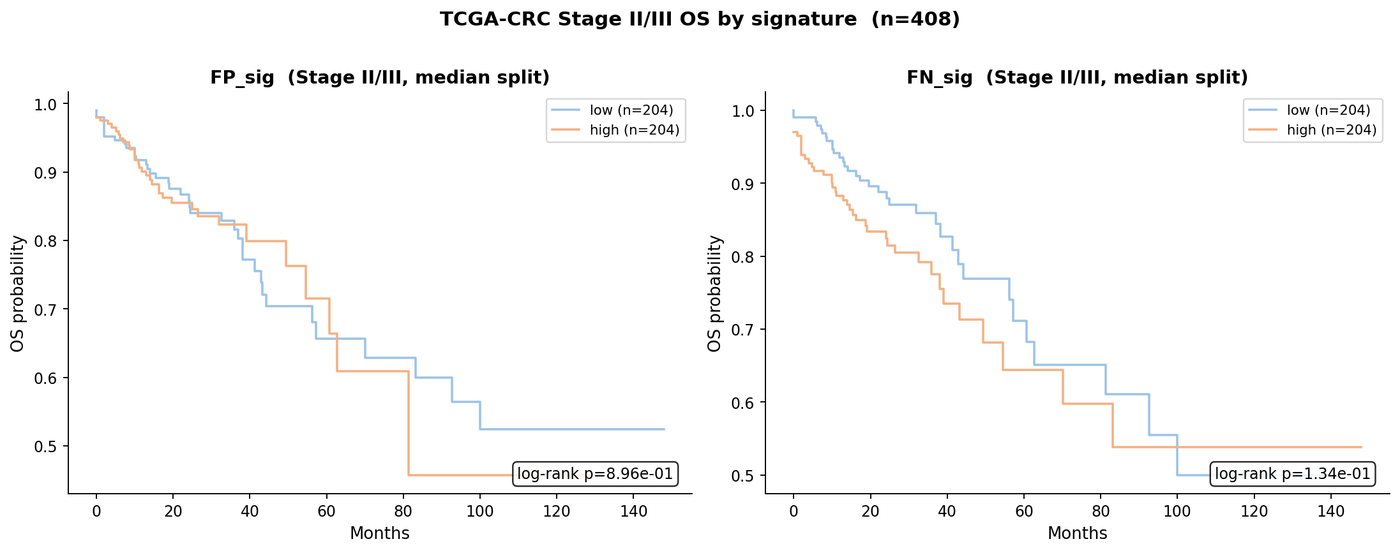

In [ ]:
# Stage II/III KM
Image(str(COMP / "signature_survival_tcga/km_subgroup_stage23.png"))